# Predicting Mobile Game "Whales": Free-to-Play Payer Conversion

**Business problem:** In free-to-play mobile games, only a small fraction of players ever spend money (often called "whales" when they spend a lot). Studios want to predict, from early player behavior, **which players are likely to convert into paying customers**,so they can target them with personalized offers, special deals, or push notifications.

**Task:** Binary Classification i.e. predict `converted_to_payer` (1 = converts to a paying user, 0 = stays free-to-play).

---
### Project Roadmap
1. Load Dataset
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Building: Logistic Regression, KNN, SVM, Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, Voting Classifier
5. Model Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC
6. Model Comparison

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Dataset

In [2]:
df = pd.read_csv("mobile_game_whale_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (12000, 26)


,player_id,age,gender,country,acquisition_channel,device_type,days_since_install,sessions_last_7d,avg_session_length_min,total_playtime_hours,levels_completed,current_level,tutorial_completed,num_friends_connected,push_notifications_enabled,ad_views,rewarded_ad_views,store_visits,items_viewed_in_store,wishlist_items,days_active_last_30,streak_days,rage_quit_events,level_fail_rate,social_shares,converted_to_payer
0,100000,29.0,Male,USA,organic,Android,9,11,9.518540,2.66,16,16,1,2.0,1,8,2,1,4,1,19,9,0,0.636,3,1
1,100001,19.0,Female,USA,paid_social,iOS,3,12,15.190548,2.91,13,14,1,2.0,1,7,2,4,9,2,24,2,5,0.755,0,0
2,100002,33.0,Male,Brazil,paid_social,Android,5,14,12.706770,4.71,28,30,1,5.0,1,6,3,4,12,2,11,24,4,0.791,1,0
3,100003,35.0,Female,India,paid_social,Android,3,10,16.310338,4.41,21,22,1,2.0,1,7,3,1,2,0,13,10,3,0.329,0,1
4,100004,13.0,Female,Indonesia,paid_search,Android,37,12,11.299238,11.50,15,16,1,4.0,0,10,3,1,3,1,24,0,3,0.732,0,0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Info & Summary Statistics

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player_id                   12000 non-null  int64  
 1   age                         11640 non-null  float64
 2   gender                      12000 non-null  object 
 3   country                     12000 non-null  object 
 4   acquisition_channel         12000 non-null  object 
 5   device_type                 12000 non-null  object 
 6   days_since_install          12000 non-null  int64  
 7   sessions_last_7d            12000 non-null  int64  
 8   avg_session_length_min      11760 non-null  float64
 9   total_playtime_hours        12000 non-null  float64
 10  levels_completed            12000 non-null  int64  
 11  current_level               12000 non-null  int64  
 12  tutorial_completed          12000 non-null  int64  
 13  num_friends_connected       114

In [4]:
df.describe()

,player_id,age,days_since_install,sessions_last_7d,avg_session_length_min,total_playtime_hours,levels_completed,current_level,tutorial_completed,num_friends_connected,push_notifications_enabled,ad_views,rewarded_ad_views,store_visits,items_viewed_in_store,wishlist_items,days_active_last_30,streak_days,rage_quit_events,level_fail_rate,social_shares,converted_to_payer
count,12000.00000,11640.000000,12000.000000,12000.000000,11760.000000,12000.000000,12000.000000,12000.000000,12000.000000,11400.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,105999.50000,27.020962,19.854500,7.115500,10.773800,4.906931,14.460417,15.449583,0.881583,2.208246,0.557583,6.280083,2.494333,1.999083,4.968417,1.052667,15.14175,3.738917,3.220250,0.590760,0.677917,0.127333
std,3464.24595,7.753278,18.954545,3.894837,5.030878,6.680178,7.427575,7.468742,0.323114,1.771875,0.496694,3.451878,1.623172,1.695088,4.755818,1.124425,5.81909,4.066771,1.902553,0.185787,0.895030,0.333360
min,100000.00000,13.000000,1.000000,0.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.011000,0.000000,0.000000
25%,102999.75000,22.000000,6.000000,4.000000,7.268623,1.160000,9.000000,10.000000,1.000000,1.000000,0.000000,4.000000,1.000000,1.000000,2.000000,0.000000,11.00000,1.000000,2.000000,0.463000,0.000000,0.000000
50%,105999.50000,27.000000,14.000000,7.000000,10.547080,2.740000,13.000000,14.000000,1.000000,2.000000,1.000000,6.000000,2.000000,2.000000,4.000000,1.000000,15.00000,2.000000,3.000000,0.603000,0.000000,0.000000
75%,108999.25000,32.000000,28.000000,9.000000,14.130007,6.022500,19.000000,20.000000,1.000000,3.000000,1.000000,8.000000,3.000000,3.000000,7.000000,2.000000,19.00000,5.000000,4.000000,0.732000,1.000000,0.000000
max,111999.00000,60.000000,90.000000,26.000000,32.519308,111.460000,51.000000,51.000000,1.000000,15.000000,1.000000,24.000000,14.000000,12.000000,41.000000,9.000000,29.00000,46.000000,14.000000,0.994000,7.000000,1.000000


### 3.2 Missing Values

age                       360
avg_session_length_min    240
num_friends_connected     600
dtype: int64


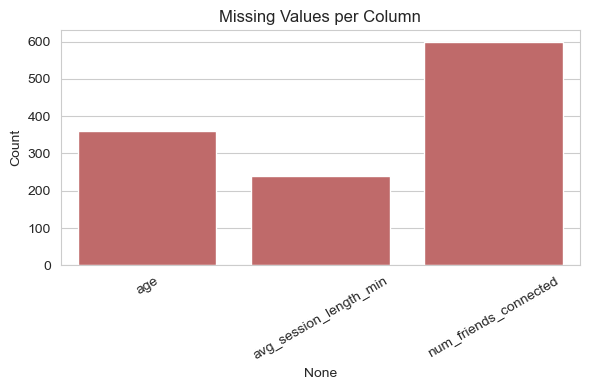

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(6,4))
sns.barplot(x=missing.index, y=missing.values, color='indianred')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.3 Target Variable Distribution

converted_to_payer
0    87.266667
1    12.733333
Name: proportion, dtype: float64


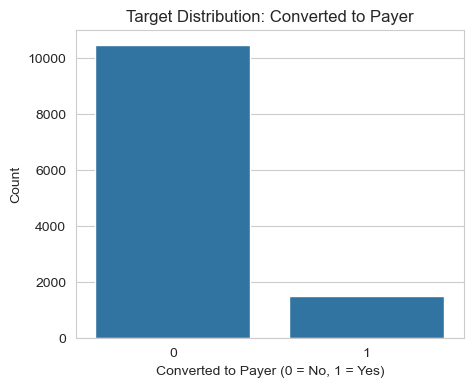

In [6]:
target_counts = df['converted_to_payer'].value_counts(normalize=True) * 100
print(target_counts)

plt.figure(figsize=(5,4))
sns.countplot(x='converted_to_payer', data=df)
plt.title("Target Distribution: Converted to Payer")
plt.xlabel("Converted to Payer (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

This is an **imbalanced classification problem**. Most players never become payers, which is realistic for this domain.

### 3.4 Numerical Feature Distributions

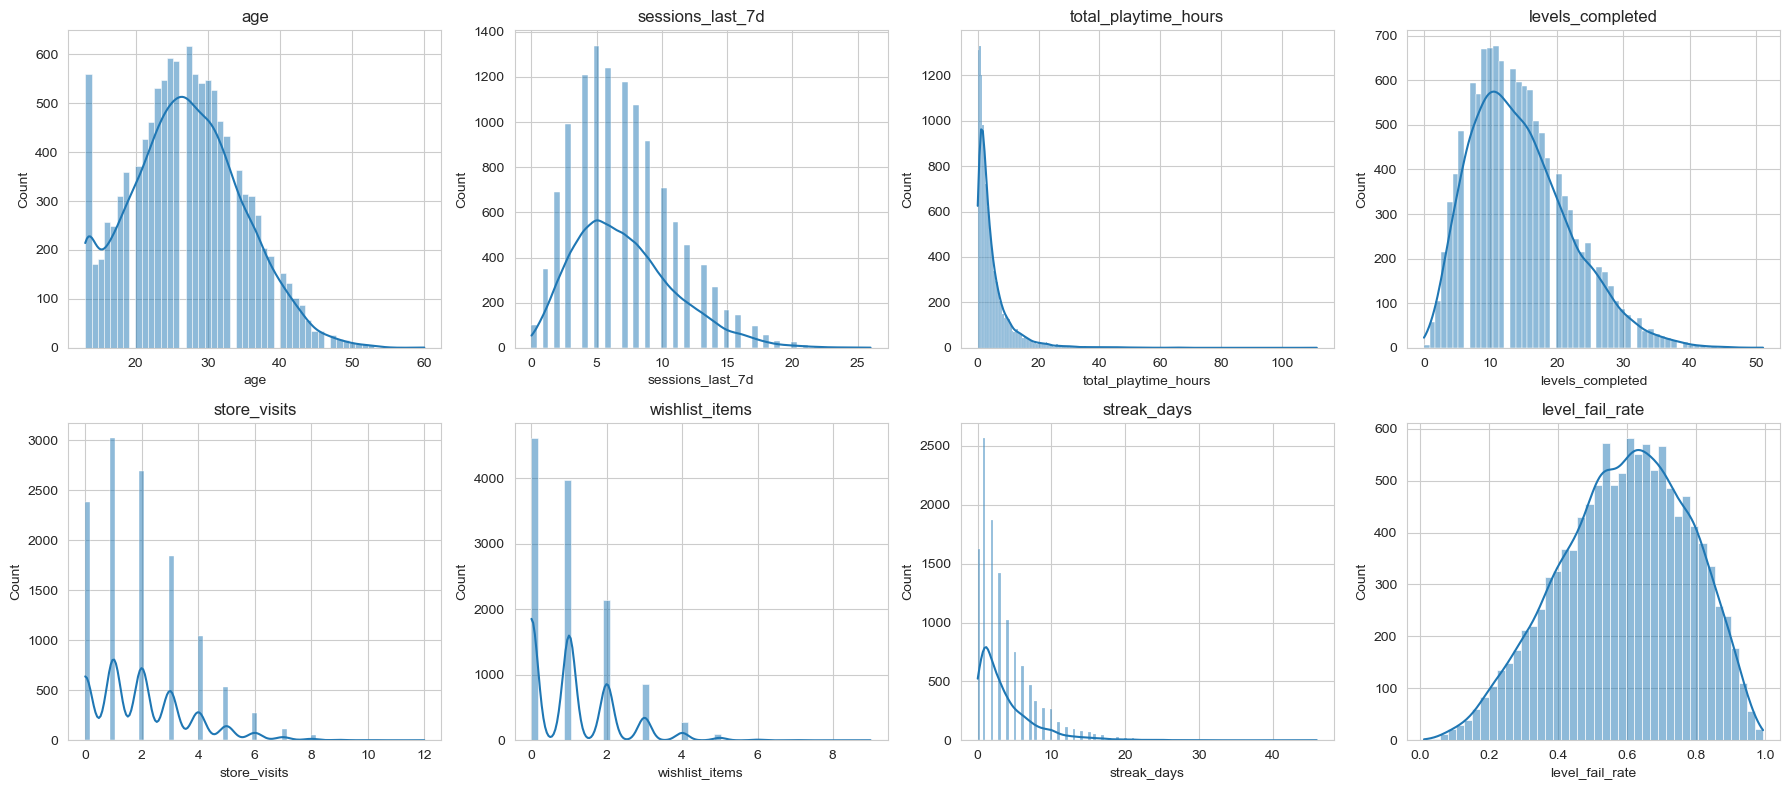

In [7]:
num_cols_plot = ['age', 'sessions_last_7d', 'total_playtime_hours', 'levels_completed',
                  'store_visits', 'wishlist_items', 'streak_days', 'level_fail_rate']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 3.5 Feature Relationships with the Target

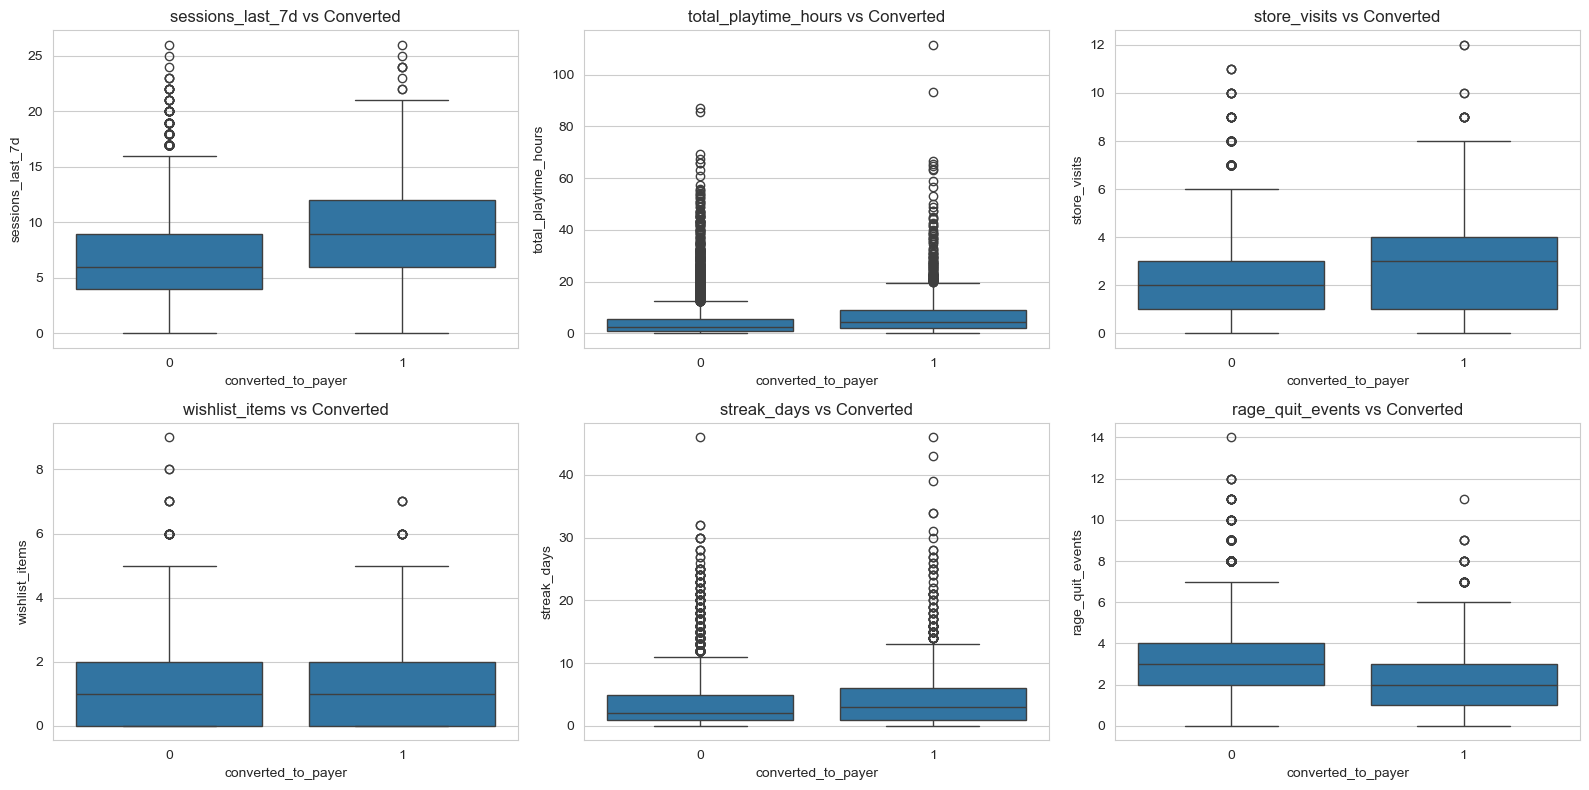

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
compare_cols = ['sessions_last_7d', 'total_playtime_hours', 'store_visits',
                 'wishlist_items', 'streak_days', 'rage_quit_events']
for i, col in enumerate(compare_cols):
    sns.boxplot(x='converted_to_payer', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Converted")
plt.tight_layout()
plt.show()

### 3.6 Categorical Features vs Target

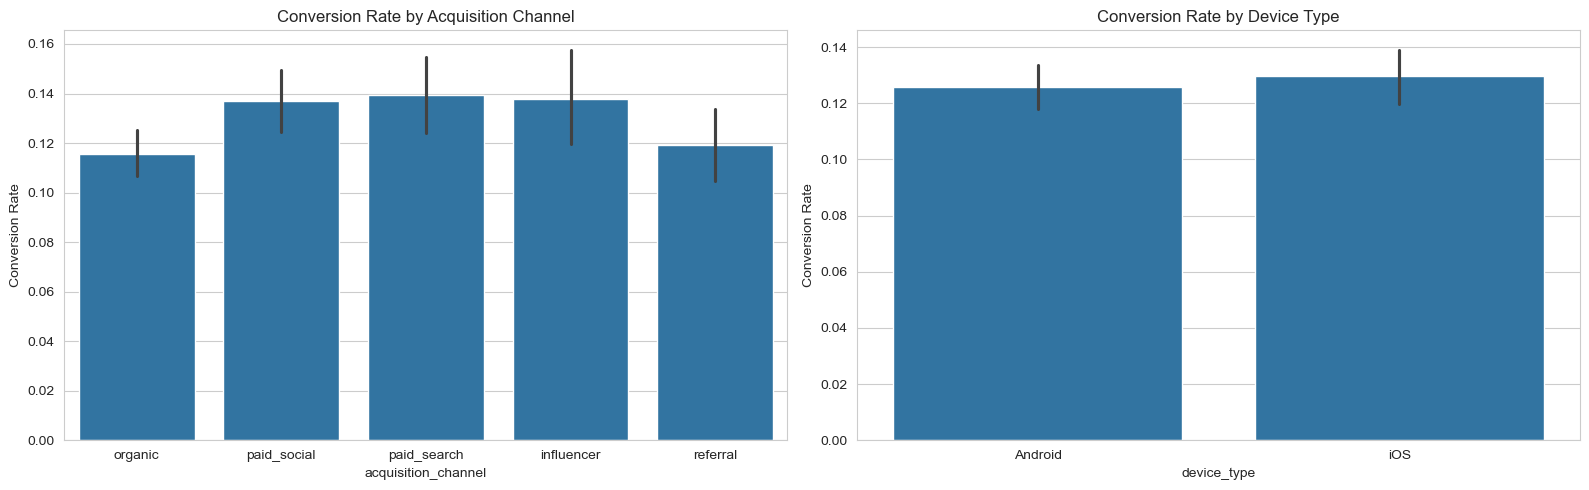

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x='acquisition_channel', y='converted_to_payer', data=df, ax=axes[0])
axes[0].set_title("Conversion Rate by Acquisition Channel")
axes[0].set_ylabel("Conversion Rate")

sns.barplot(x='device_type', y='converted_to_payer', data=df, ax=axes[1])
axes[1].set_title("Conversion Rate by Device Type")
axes[1].set_ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

### 3.7 Correlation Heatmap (Numerical Features)

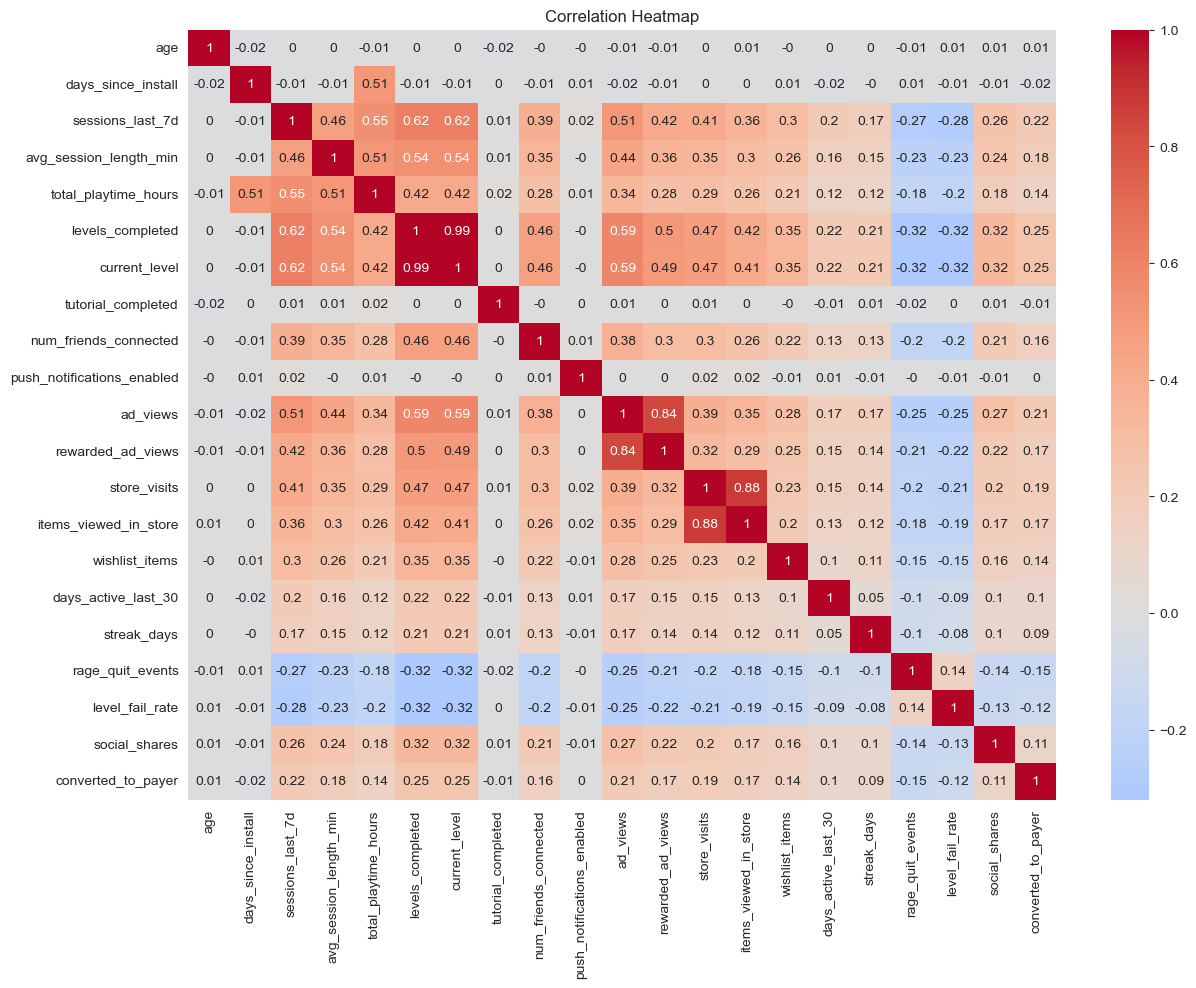

In [10]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['player_id'])
corr = round(numeric_df.corr(),2)
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## 4. Data Preprocessing

Steps:
1. Drop identifier column (`player_id`)
2. Separate features (`X`) and target (`y`)
3. Train-test split (stratified, since the target is imbalanced)
4. Handle missing values (median for numeric, mode for categorical)
5. Encode categorical variables (One-Hot Encoding)
6. Feature scaling (needed for Logistic Regression, KNN, SVM i.e. distance/gradient based algorithms)

We'll use a `ColumnTransformer` + `Pipeline` so every model gets **identical, leak-free preprocessing** (fit only on training data, applied to test data).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [12]:
df.drop("player_id",axis=1,inplace=True)

In [13]:
target = "converted_to_payer"
X = df.drop(columns=target)
y = df[target]

In [14]:
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'days_since_install', 'sessions_last_7d', 'avg_session_length_min', 'total_playtime_hours', 'levels_completed', 'current_level', 'tutorial_completed', 'num_friends_connected', 'push_notifications_enabled', 'ad_views', 'rewarded_ad_views', 'store_visits', 'items_viewed_in_store', 'wishlist_items', 'days_active_last_30', 'streak_days', 'rage_quit_events', 'level_fail_rate', 'social_shares']
Categorical columns: ['gender', 'country', 'acquisition_channel', 'device_type']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (9600, 24)
Test shape: (2400, 24)

Train target distribution:
 converted_to_payer
0    0.872708
1    0.127292
Name: proportion, dtype: float64

Test target distribution:
 converted_to_payer
0    0.8725
1    0.1275
Name: proportion, dtype: float64


In [16]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [17]:
cat_cols

['gender', 'country', 'acquisition_channel', 'device_type']

## 5. Model Building & Evaluation

For each algorithm we:
1. Build a `Pipeline` = preprocessing + model
2. Fit on the training set
3. Predict on the test set
4. Report **Accuracy, Precision, Recall, F1-score, ROC-AUC**, plus a confusion matrix

We'll store every model's metrics in a `results` list so we can compare them all at the end.

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

results = []          # to store metrics for final comparison
fitted_models = {}    # to store fitted pipelines for ROC curve comparison

def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    print(f"===== {name} =====")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Converted', 'Converted'],
                yticklabels=['Not Converted', 'Converted'])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1 Score': f1, 'ROC-AUC': auc
    })
    fitted_models[name] = pipeline
    return pipeline

### 5.1 Logistic Regression

In [19]:
X_test

,age,gender,country,acquisition_channel,device_type,days_since_install,sessions_last_7d,avg_session_length_min,total_playtime_hours,levels_completed,current_level,tutorial_completed,num_friends_connected,push_notifications_enabled,ad_views,rewarded_ad_views,store_visits,items_viewed_in_store,wishlist_items,days_active_last_30,streak_days,rage_quit_events,level_fail_rate,social_shares
3653,33.0,Female,USA,paid_search,Android,32,5,9.207993,5.50,20,21,1,1.0,0,2,1,2,6,0,19,4,4,0.377,0
11454,37.0,Male,India,organic,iOS,12,5,14.019943,2.04,14,15,1,3.0,1,4,1,3,9,2,17,2,2,0.762,1
4321,28.0,Female,India,paid_search,Android,28,17,9.942922,7.20,18,19,1,7.0,1,12,7,7,9,2,20,7,3,0.574,1
7541,24.0,Male,Germany,organic,Android,34,3,17.055148,5.40,10,11,1,4.0,0,11,5,2,8,0,7,2,4,0.534,1
3968,22.0,Female,Philippines,paid_search,iOS,14,14,18.381888,13.29,23,25,1,2.0,0,7,3,4,14,3,15,0,1,0.630,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8618,27.0,Male,UK,paid_social,Android,57,13,10.139289,10.19,19,19,1,2.0,1,10,6,3,5,3,19,8,2,0.376,2
8412,21.0,Female,Indonesia,paid_social,Android,90,8,19.267753,22.22,21,22,1,7.0,1,9,4,6,13,2,11,7,6,0.615,0
10998,25.0,Male,USA,organic,Android,15,2,5.050347,0.67,15,16,1,2.0,1,8,3,0,0,0,16,2,4,0.885,1
4689,22.0,Female,Indonesia,paid_social,Android,20,16,16.683110,18.99,34,36,1,6.0,0,9,3,4,15,2,18,6,3,0.530,1


===== Logistic Regression =====
Accuracy  : 0.8725
Precision : 0.5000
Recall    : 0.0458
F1 Score  : 0.0838
ROC-AUC   : 0.7295

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93      2094
           1       0.50      0.05      0.08       306

    accuracy                           0.87      2400
   macro avg       0.69      0.52      0.51      2400
weighted avg       0.83      0.87      0.82      2400



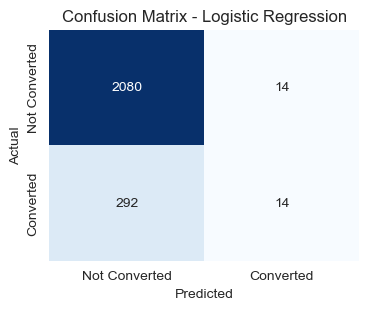

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

evaluate_model("Logistic Regression", logreg_pipeline, X_train, y_train, X_test, y_test)


### 5.2 K-Nearest Neighbors (KNN)

===== KNN =====
Accuracy  : 0.8617
Precision : 0.3194
Recall    : 0.0752
F1 Score  : 0.1217
ROC-AUC   : 0.5916

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.92      2094
           1       0.32      0.08      0.12       306

    accuracy                           0.86      2400
   macro avg       0.60      0.53      0.52      2400
weighted avg       0.81      0.86      0.82      2400



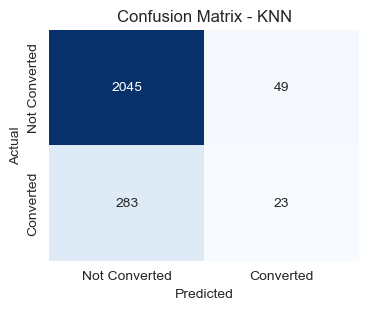

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

evaluate_model("KNN", knn_pipeline, X_train, y_train, X_test, y_test)


### 5.3 Support Vector Machine (SVM)

===== SVM =====
Accuracy  : 0.8733
Precision : 0.6667
Recall    : 0.0131
F1 Score  : 0.0256
ROC-AUC   : 0.6190

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93      2094
           1       0.67      0.01      0.03       306

    accuracy                           0.87      2400
   macro avg       0.77      0.51      0.48      2400
weighted avg       0.85      0.87      0.82      2400



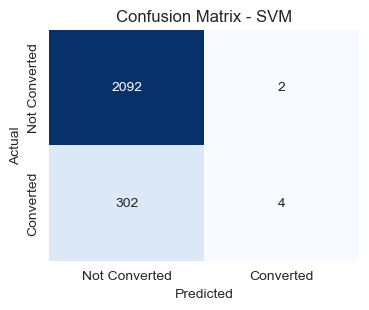

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
])

evaluate_model("SVM", svm_pipeline, X_train, y_train, X_test, y_test)


### 5.4 Decision Tree

===== Decision Tree =====
Accuracy  : 0.7788
Precision : 0.1720
Recall    : 0.1928
F1 Score  : 0.1818
ROC-AUC   : 0.5286

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      2094
           1       0.17      0.19      0.18       306

    accuracy                           0.78      2400
   macro avg       0.53      0.53      0.53      2400
weighted avg       0.79      0.78      0.78      2400



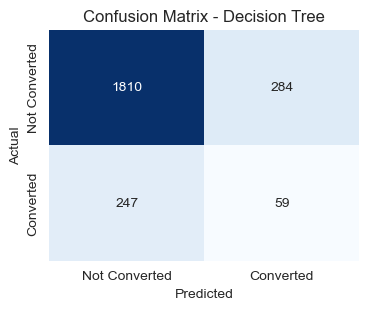

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

evaluate_model("Decision Tree", dt_pipeline, X_train, y_train, X_test, y_test)


### 5.5 Bagging Classifier

===== Bagging (Decision Trees) =====
Accuracy  : 0.8696
Precision : 0.4146
Recall    : 0.0556
F1 Score  : 0.0980
ROC-AUC   : 0.6826

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93      2094
           1       0.41      0.06      0.10       306

    accuracy                           0.87      2400
   macro avg       0.65      0.52      0.51      2400
weighted avg       0.82      0.87      0.82      2400



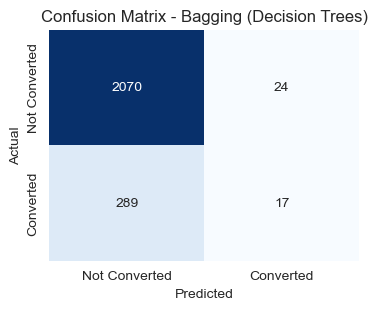

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
from sklearn.ensemble import BaggingClassifier

bagging_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                                 n_estimators=50, random_state=RANDOM_STATE))
])

evaluate_model("Bagging (Decision Trees)", bagging_pipeline, X_train, y_train, X_test, y_test)


### 5.6 Random Forest (Bagging Ensemble)

===== Random Forest =====
Accuracy  : 0.8721
Precision : 0.4737
Recall    : 0.0294
F1 Score  : 0.0554
ROC-AUC   : 0.7011

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93      2094
           1       0.47      0.03      0.06       306

    accuracy                           0.87      2400
   macro avg       0.67      0.51      0.49      2400
weighted avg       0.82      0.87      0.82      2400



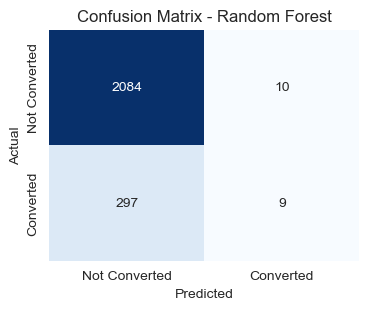

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

evaluate_model("Random Forest", rf_pipeline, X_train, y_train, X_test, y_test)


### 5.7 AdaBoost (Boosting)

===== AdaBoost =====
Accuracy  : 0.8721
Precision : 0.4615
Recall    : 0.0196
F1 Score  : 0.0376
ROC-AUC   : 0.7152

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93      2094
           1       0.46      0.02      0.04       306

    accuracy                           0.87      2400
   macro avg       0.67      0.51      0.48      2400
weighted avg       0.82      0.87      0.82      2400



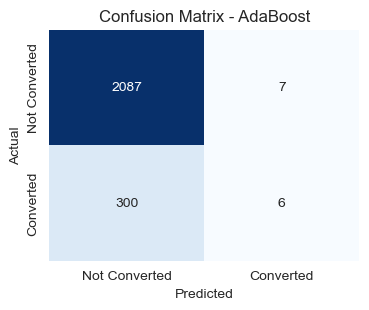

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

evaluate_model("AdaBoost", adaboost_pipeline, X_train, y_train, X_test, y_test)


### 5.8 Gradient Boosting

===== Gradient Boosting =====
Accuracy  : 0.8717
Precision : 0.4706
Recall    : 0.0523
F1 Score  : 0.0941
ROC-AUC   : 0.7282

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93      2094
           1       0.47      0.05      0.09       306

    accuracy                           0.87      2400
   macro avg       0.67      0.52      0.51      2400
weighted avg       0.83      0.87      0.82      2400



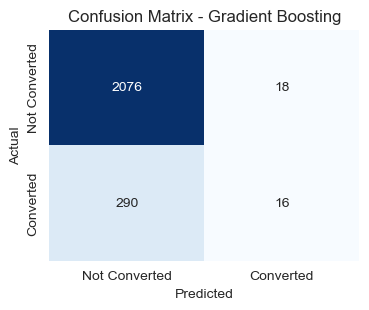

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

evaluate_model("Gradient Boosting", gb_pipeline, X_train, y_train, X_test, y_test)


### 5.9 Voting Classifier (combining multiple models)

===== Voting Classifier =====
Accuracy  : 0.8538
Precision : 0.3009
Recall    : 0.1111
F1 Score  : 0.1623
ROC-AUC   : 0.6857

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      2094
           1       0.30      0.11      0.16       306

    accuracy                           0.85      2400
   macro avg       0.59      0.54      0.54      2400
weighted avg       0.81      0.85      0.82      2400



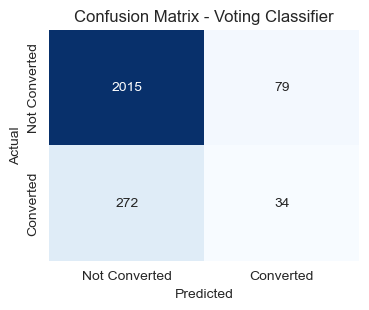

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
from sklearn.ensemble import VotingClassifier

voting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
            ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
            ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE))
        ],
        voting='soft'
    ))
])

evaluate_model("Voting Classifier", voting_pipeline, X_train, y_train, X_test, y_test)


## 6. Model Comparison

In [29]:
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.872500,0.500000,0.045752,0.083832,0.729460
1,Gradient Boosting,0.871667,0.470588,0.052288,0.094118,0.728198
2,AdaBoost,0.872083,0.461538,0.019608,0.037618,0.715220
3,Random Forest,0.872083,0.473684,0.029412,0.055385,0.701111
4,Voting Classifier,0.853750,0.300885,0.111111,0.162291,0.685694
5,Bagging (Decision Trees),0.869583,0.414634,0.055556,0.097983,0.682555
6,SVM,0.873333,0.666667,0.013072,0.025641,0.619038
7,KNN,0.861667,0.319444,0.075163,0.121693,0.591613
8,Decision Tree,0.778750,0.172012,0.192810,0.181818,0.528592


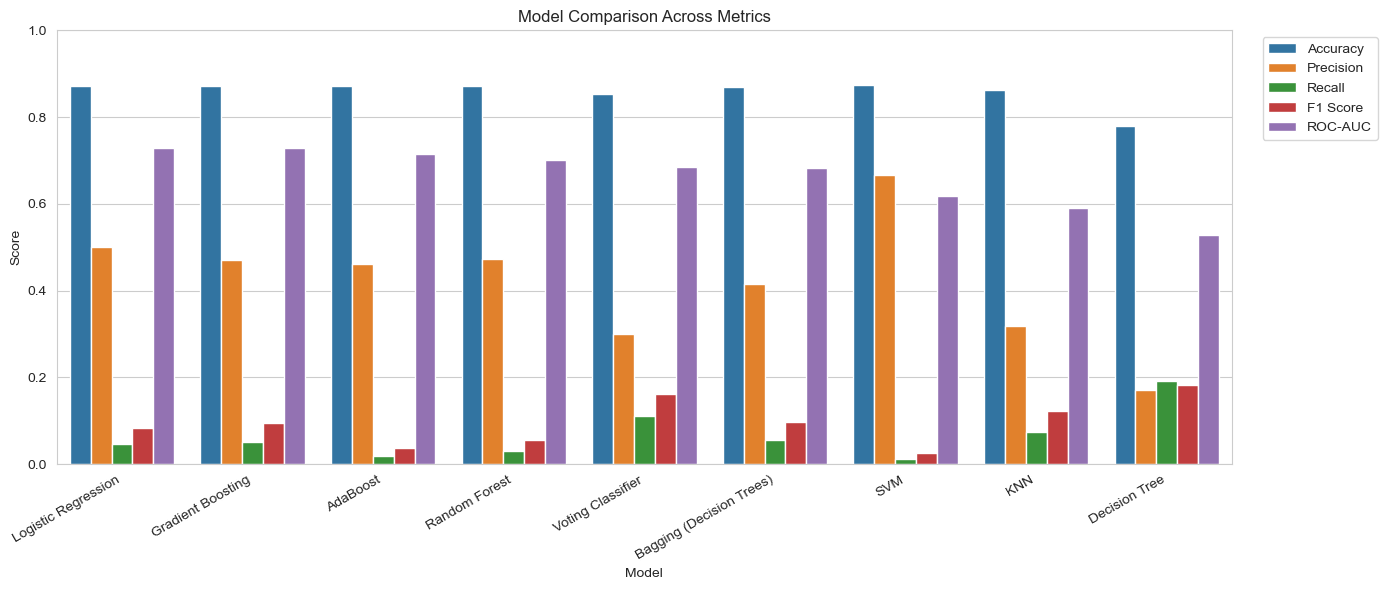

In [30]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title("Model Comparison Across Metrics")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.1 ROC Curve Comparison

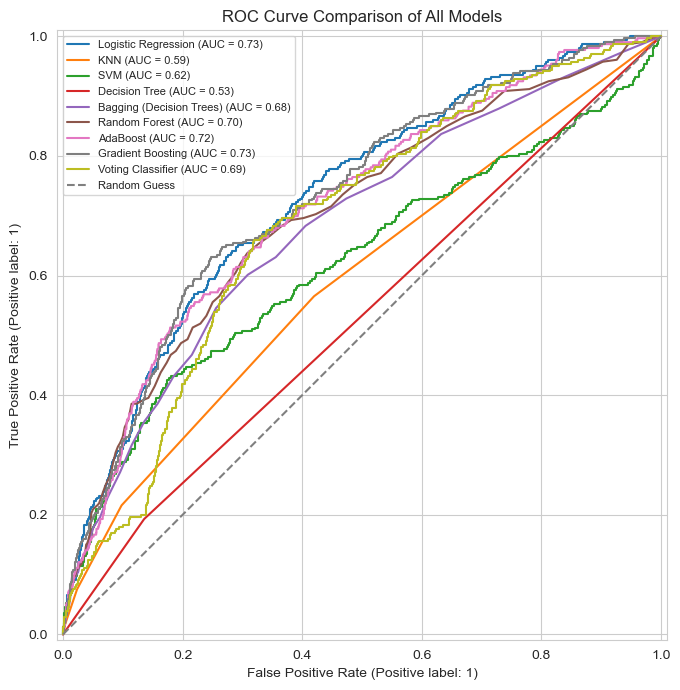

In [31]:
plt.figure(figsize=(9, 7))
ax = plt.gca()
for name, pipeline in fitted_models.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.title("ROC Curve Comparison of All Models")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Observations

- Take note of which models have **high accuracy but low recall**, with only ~13% of players converting, a model can score well on accuracy just by predicting "no conversion" most of the time. That is why **accuracy alone is misleading for imbalanced data**, and Precision/Recall/F1/ROC-AUC matter more here.
- Tree-based ensembles (Random Forest, Gradient Boosting, AdaBoost) generally handle the non-linear engagement patterns better than a plain Decision Tree or KNN.
- All models above were evaluated using their **default hyperparameters** and a **single train/test split**, so these numbers are only a first look.

---
## 8. Cross-Validation & Hyperparameter Tuning

Topics to cover next:
- K-Fold Cross-Validation (`cross_val_score`, `StratifiedKFold`)
- `GridSearchCV` / `RandomizedSearchCV` for each model
- Comparing cross-validated performance vs. the single-split results above
- Selecting final tuned models and re-evaluating on the test set


In [33]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, GridSearchCV, RandomizedSearchCV
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Define the final pipeline with Logistic Regression (default parameters, or tuned if you wish)
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Evaluate with cross-validation (optional, but recommended)
cv_scores_final = cross_val_score(final_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-validated ROC-AUC for Logistic Regression: {cv_scores_final.mean():.4f} (+/- {cv_scores_final.std():.4f})")

# Fit the final model on the entire training set
final_model.fit(X_train, y_train)

Cross-validated ROC-AUC for Logistic Regression: 0.7302 (+/- 0.0204)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
import joblib
import os

# Ensure the directory exists
os.makedirs("models", exist_ok=True)

# Save the final pipeline
joblib.dump(final_model, "models/whale_prediction_model.pkl")
print("Model saved to models/whale_prediction_model.pkl")

Model saved to models/whale_prediction_model.pkl


In [36]:
!Stramlib run app.py

'Stramlib' is not recognized as an internal or external command,
operable program or batch file.
